# Predicting Success with Machine Learning 

In this notebook we will use machine learning techniques to predict the success of a series based on its early performance. In particular we will say a series is *successful* if it runs for at least 50 chapters and *unsuccessful* if it runs for less than 50 chapters.  We will only consider the performance of the first 12 chapters in making our prediction. 

## Basis Size and Success Criteria

If we want to adjust how many first chapters are used or how many chapters a series must publish in order to be considered a success we can do so below.

In [1]:
# How many chapters we should consider when making the prediction.
basis_size=12

# The minimum number of chapters for a series to be considered a success.
success_criteria=50

# Loading Libraries

This project requires numerous Python libraries which are loaded below.

In [ ]:
# We will obtain data from the SQlite database.
import sqlite3

# We will use the following for handling data and creating figures and charts.
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# We use the following for preprocessing data and evaluating models.
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split, LeaveOneOut, cross_val_score, GridSearchCV
from sklearn.feature_selection import RFECV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
from sklearn.base import clone

# We employ a suite of models to determine which may work best.
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

# We use pickle to save the best model.
import pickle

# We set the seed for replicability.
np.random.seed(1)


# Obtaining Data

We will use data taken from our SQLite database. In this section we perform the necessary work to obtain a Pandas dataframe where each row corresponds to a series in the magazine and each column represents a feature which might indicate early success or failure.  First we connect to the database and note the current range of dates.

In [3]:
connection=sqlite3.connect('shonen_jump_demo.sqlite3')
cursor=connection.cursor()
cursor.execute("""SELECT MIN(release_date), MAX(release_date) FROM chapters;""")
date_range=cursor.fetchone()

In [4]:
print(f"When this notebook was last run the demo database contained chapters between {date_range[0]} and {date_range[1]}.")

When this notebook was last run the demo database contained chapters between 2022-01-16 and 2025-11-09.


Next we query the database to gather information on series whose early performance and ultimate success/failure is known so that we can obtain a dataset for training our model.  Read the comments inside the query for a better understanding of what columns are being assembled.  Each row of the resulting query corresponds to one series.

In [5]:
df=pd.read_sql_query("""
-- We want the name and genre of each series.                     
SELECT title,genre,  
-- Next we want an indicator column where 1 indicates that the series has one creator (who both writes and draws) and 
-- 0 if the series has a different artist and writer.  We call this column one_creator.
CASE
WHEN writer=artist THEN 1
ELSE 0 END one_creator,
-- We create a second indicator which produces 1 if the series is successful (runs for at least success_criteria chapters)
-- and 0 otherwise.  We call this column success.              
CASE
WHEN total_chapters>=:success_criteria THEN 1
ELSE 0 END success,
-- We also want to track what the average placement of the series was, how many color pages it received, and how many times it landed
-- on the cover page over its first basis_size number of chapters. These columns will be obtained below.
average_placement,
color_pages,
cover_pages,
-- Finally we want the debut date and the size of the batch the series started in.
debuts.release_date,
batches.added AS batch_size

-- We now begin obtaining the above columns and selecting series where we know both their early performance and overall success/failure. 
FROM series
-- By inner joining with debuts we restrict ourselves to series where the database includes chapters starting from 1.
INNER JOIN debuts ON title=debuts.series
-- We join with a selection which averages the placement of each series over its first basis_size chapters
LEFT JOIN (SELECT AVG(placement) AS average_placement, series FROM chapters
WHERE chapter<=:basis_size GROUP BY series) AS avplace
ON title=avplace.series
-- We join again with a selection which counts the number of color pages over the series' first basis_size chapters.
LEFT JOIN (SELECT series,COUNT(series) AS color_pages FROM chapters
WHERE type='Color' AND chapter<=:basis_size
GROUP BY series) AS colorp
ON title=colorp.series
-- We join again with a selection which counts the number of cover pages over the series' first basis_size chapters.
LEFT JOIN (SELECT series,COUNT(series) AS cover_pages FROM chapters
WHERE type='Cover' AND chapter<=:basis_size
GROUP BY series) AS coverp
ON title=coverp.series
-- We also join with batches by associating to each series' debut the batch it lands within.
LEFT JOIN batches ON debuts.release_date BETWEEN batches.start_date AND batches.end_date
-- Finally we only select series who have achieved success by our criteria or have completed.
WHERE total_chapters>=:success_criteria OR status="Complete"
ORDER BY title;
                """, con=connection, params={'basis_size':basis_size,'success_criteria':success_criteria})

Summarizing the comments in the above SQL query we have that the resulting dataframe only includes series which satisfy the following conditions:

1. The database has information on the series starting from chapter 1. We aren't considering series which started before the earliest date in the database even if we have information on later chapters.
2. The success or failure of the series is currently known, i.e. either:
    * The series has run for at least `success_criteria` chapters (it succeeded).
    * The series is completed (and can be said to have failed if it didn't reach `success_criteria` chapters).

Where 1 ensures we have information on starting success and 2 ensures we have information on overall success or failure.

In [6]:
# We close the connection now that we have obtained all the information from the database we need.
connection.close()

# Data Overview and Feature Engineering

The dataset requires little cleaning because the SQL query eliminated most unnecessary information or series where we lacked sufficient information to use for training purposes. 

In [7]:
df

,title,genre,one_creator,success,average_placement,color_pages,cover_pages,release_date,batch_size
0,Akane-banashi,Other,0,1,7.750000,2,1,2022-02-13,2
1,Aliens Area,Battle,1,0,11.416667,2,1,2022-06-05,3
2,Astro Royale,Battle,1,1,8.500000,2,1,2024-04-14,3
3,Cipher Academy,Other,0,1,10.250000,1,1,2022-11-20,4
4,Dear Anemone,Battle,1,0,12.250000,1,1,2024-02-18,2
5,Do Retry,Sports,1,0,13.000000,1,1,2023-05-07,4
6,Earthchild,Other,1,0,9.666667,2,1,2022-02-20,2
7,Ekiden Bros,Sports,1,0,12.666667,1,1,2025-06-29,4
8,Embers,Sports,0,0,12.500000,1,1,2025-02-02,2
9,Fabricant 100,Battle,1,0,11.250000,1,1,2022-12-04,4


A quick inspection reveals that all series had exactly one cover page.  We can remove this column.

In [8]:
df.drop(columns=['cover_pages'],inplace=True)

We will extract the year and month from the release_date column.

In [9]:
df['release_date']=pd.to_datetime(df['release_date'])
df['release_year']=df['release_date'].dt.year
df['release_month']=df['release_date'].dt.month

## Previewing Data

We will create a few simple figures to sense trends in the data and get an idea what might indicate the success of a series.

In [10]:
df.corr(numeric_only=True)

,one_creator,success,average_placement,color_pages,batch_size,release_year,release_month
one_creator,1.000000,-0.300765,0.199587,-0.092588,-0.057033,0.098614,0.096690
success,-0.300765,1.000000,-0.622805,0.499304,0.144177,0.002851,-0.092823
average_placement,0.199587,-0.622805,1.000000,-0.803943,0.027453,0.320007,-0.037702
color_pages,-0.092588,0.499304,-0.803943,1.000000,-0.224892,-0.248773,-0.022918
batch_size,-0.057033,0.144177,0.027453,-0.224892,1.000000,-0.076262,0.172684
release_year,0.098614,0.002851,0.320007,-0.248773,-0.076262,1.000000,-0.346699
release_month,0.096690,-0.092823,-0.037702,-0.022918,0.172684,-0.346699,1.000000


Examining the correlation of factors we see that success is negatively correlated with placement. A larger (worse) placement is correlated with less success.  At the same time, the number of color pages is positively correlated with success.  It is worth observing that average placement and the number of color pages are also highly correlated.

<Axes: xlabel='average_placement'>

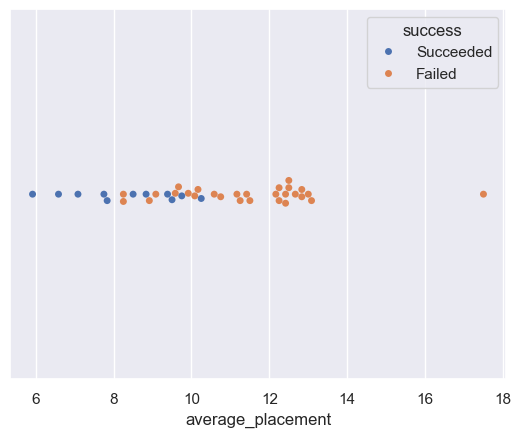

In [11]:
sns.set()
sns.swarmplot(df.replace({'success':{0:'Failed',1:'Succeeded'}}),x='average_placement', hue='success')

Of the series examined it seems that an average placement of around 10 is a cutoff point-- only one series which had a worse average placement managed to succeed.  On the other hand all five series which had an average placement of 8 or higher ended up succeeding.

<Axes: xlabel='genre', ylabel='count'>

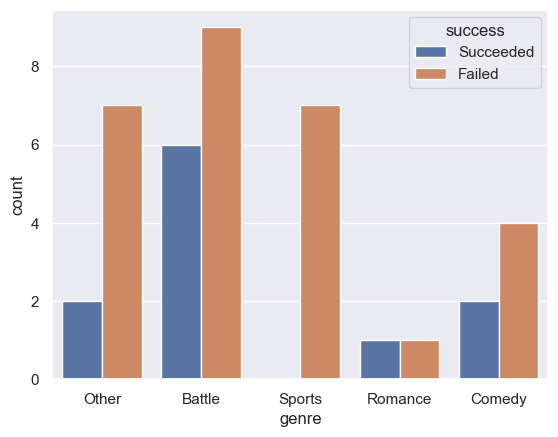

In [12]:
sns.countplot(df.replace({'success':{0:'Failed',1:'Succeeded'}}),x='genre',hue='success')

Sports stands out for having a very low success rate among the represented series.

<Axes: xlabel='batch_size', ylabel='count'>

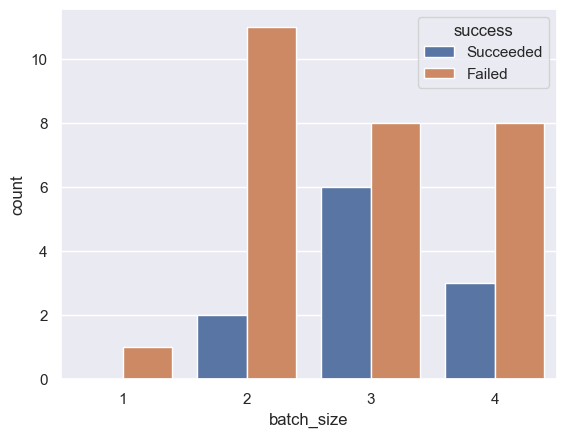

In [13]:
sns.countplot(df.replace({'success':{0:'Failed',1:'Succeeded'}}),x='batch_size',hue='success', hue_order=['Succeeded','Failed'])

It seems as if a batch size higher than 2 series may increase the odds of a series lasting for longer.

<Axes: xlabel='one_creator', ylabel='count'>

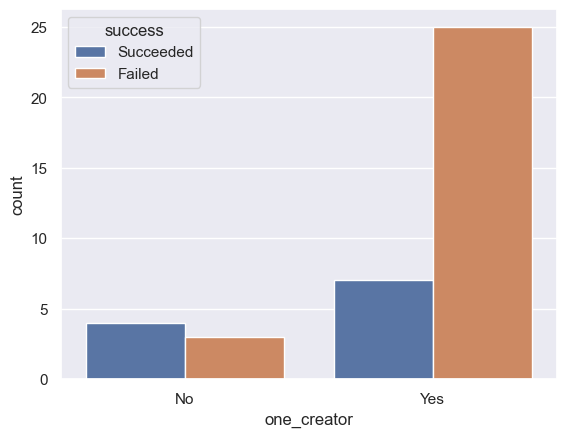

In [14]:
sns.countplot(df.replace({'success':{0:'Failed',1:'Succeeded'}, 'one_creator':{0:"No",1:'Yes'}}),
              x='one_creator',hue='success', hue_order=['Succeeded','Failed'])

Series with a separate writer and author have a higher success rate in the sample set.

## Combining Observations

From the swarm plot we might assume that it is easy to predict the success of series with an average placement better than 8 and the failure of a series with an average placement worse than 10.  But what about series in the middle?  We look to see if there is another criteria which might split the remaining data into two easy to predict blocks.

In [15]:
# Selecting series with middling placements.
middle_series=df[(df['average_placement']>8) & (df['average_placement']<10)]
middle_series

,title,genre,one_creator,success,average_placement,color_pages,release_date,batch_size,release_year,release_month
2,Astro Royale,Battle,1,1,8.500000,2,2024-04-14,3,2024,4
6,Earthchild,Other,1,0,9.666667,2,2022-02-20,2,2022,2
10,Ginka & Glüna,Battle,1,0,9.083333,2,2022-09-11,2,2022,9
16,Ichigoki's Under Control!!,Comedy,1,0,9.916667,1,2022-11-27,4,2022,11
18,Kagurabachi,Battle,1,1,9.384615,2,2023-09-17,3,2023,9
22,Martial Master Asumi,Sports,1,0,8.250000,3,2023-06-18,2,2023,6
24,Nue's Exorcist,Battle,1,1,8.833333,2,2023-05-14,4,2023,5
28,Shinobi Undercover,Battle,0,1,9.500000,2,2024-09-15,3,2024,9
31,Super Smartphone,Other,0,0,9.583333,2,2022-05-08,3,2022,5
34,The Ichinose Family's Deadly Sins,Other,1,0,8.250000,2,2022-11-13,4,2022,11


<Axes: xlabel='color_pages', ylabel='count'>

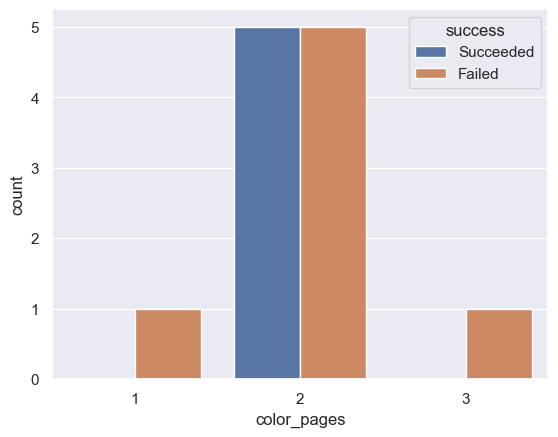

In [16]:
sns.countplot(middle_series.replace({'success':{0:'Failed',1:'Succeeded'}}),
              x='color_pages',hue='success', hue_order=['Succeeded','Failed'])

Although the only successful series from this middle cut all had 2 color pages, most of the ones which failed also had 2.  This may not be a useful axis to predict with.

<Axes: xlabel='genre', ylabel='count'>

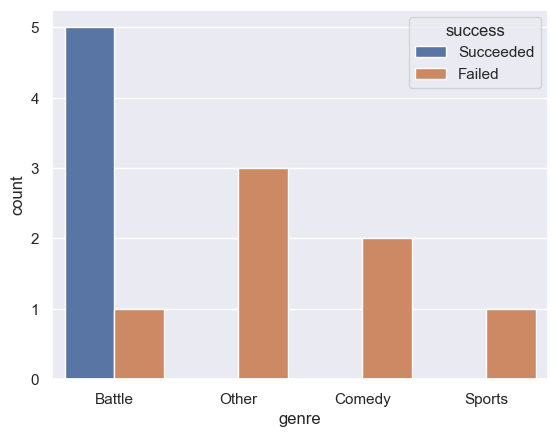

In [17]:
sns.countplot(middle_series.replace({'success':{0:'Failed',1:'Succeeded'}}),
              x='genre',hue='success', hue_order=['Succeeded','Failed'])

The above figure indicates that among the series with middling average placements those belonging to the Battle genre were the only ones to succeed (and almost all that were Battle manga *did* succeed). This might be a useful criteria in predicting the success of a series. 

# Model Creation

In this section we will create a model to predict the success of a series based on information about its initial performance in the table of contents.

## Intuition

From the above figures we might intuitively think one method of determining whether a series succeeds would be to first split the data along one axis, say the average placement in the table of contents.  Then we can predict ambiguous series using a second criteria, such as genre.  For example we could employ the following simple prediction technique:

1. If a series has an average placement better than 8 we predict it succeeds.
2. If a series has an average placement worse than 10 we predict it fails.
3. If a series has an average placement between 8 and 10 we consider its genre to make a prediction.
* If the genre is Battle we predict it succeeds.
* If the genre is any other we predict it fails.

This process is precisely the kind required in making a decision tree. We will create a simple tree using sklearn to demonstrate the process.

In [18]:
# We create a set of preprocessing steps to perform on different columns of our dataframe-- encoding the categorical columns
# and dropping any unneeded columns.
tree_transformers=[('OneHotEncoding', OneHotEncoder(sparse_output=False),['genre', 'release_month']),
              ('Column Dropper', 'drop', ['title','release_date'])]

# We define the preprocesser using the transformers defined above. 
tree_preprocessor=ColumnTransformer(transformers=tree_transformers,remainder='passthrough',force_int_remainder_cols=False, verbose_feature_names_out=False)

# We process the data
tree_data=tree_preprocessor.fit_transform(df.drop(['success'],axis=1))

# We extract the feature names.
tree_features=tree_preprocessor.get_feature_names_out()


# We create a decision tree classifier which we will fit using tree_data.
demo_tree=DecisionTreeClassifier(random_state=3)

# We fit the classifier on our dataset.
demo_tree.fit(tree_data,df['success'])

# We extract the class names.
tree_classes=pd.Series(demo_tree.classes_).map({0:'Fail',1:'Succeed'})


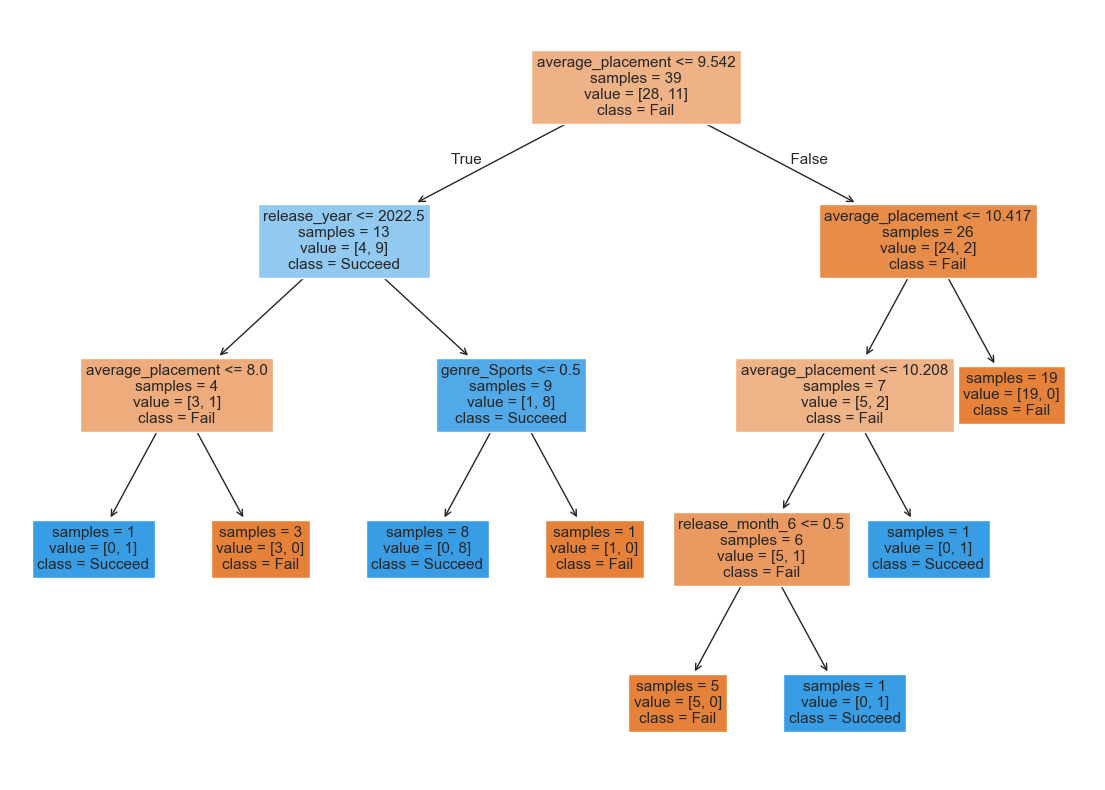

In [19]:
plt.figure(figsize=(14,10))
plot_tree(demo_tree, feature_names=tree_features, fontsize=11, class_names=tree_classes, impurity=False, filled=True)
plt.show()

In the above plot a node is colored blue if the majority of its samples are successes and orange if the majority are failures. Following the right hand side of the tree, we notice that the tree first checks if the average placement is above or below 9.542. For samples with a worse rating, it then checks whether the placement is above or below 10.417. The leaf that follows (the 19 series with average placement larger than 10.417) includes only failures.  

The above decision tree risks overfitting the training data. When selecting the optimal model we will use cross validation to better judge the quality of the model on unseen data.

## Strategy

Because the dataset is small we will not split into a training and testing portion.  Instead, we will rely on a leave one out cross validation strategy to select the best possible model from a grid search.  Our plan is as follows:

1. Create a preprocessing transformer to prepare the data for the model (since many models cannot handle non-numerical data or perform better with scaled values).
2. Create a feature selector to limit the number of features considered when fitting the model.
3. Develop a list of models and parameters for each.
4. Create a pipeline that will preprocess, perform feature selection, and then classify.
5. Perform a grid search to determine which combination of features, model, and model parameters performs the most effectively.
6. Save the model for future testing as more data is obtained and the database expands.

### Preprocessor

We will create a preprocessor as we did for the decision tree. Before doing so we will verify the contents of each column to determine the most fitting transformers to apply.

In [20]:
df.head()

,title,genre,one_creator,success,average_placement,color_pages,release_date,batch_size,release_year,release_month
0,Akane-banashi,Other,0,1,7.750000,2,2022-02-13,2,2022,2
1,Aliens Area,Battle,1,0,11.416667,2,2022-06-05,3,2022,6
2,Astro Royale,Battle,1,1,8.500000,2,2024-04-14,3,2024,4
3,Cipher Academy,Other,0,1,10.250000,1,2022-11-20,4,2022,11
4,Dear Anemone,Battle,1,0,12.250000,1,2024-02-18,2,2024,2


Genre and release month are categorical variables and will need to be encoded. Average placement, color pages, and batch size can all be scaled.  We will drop title and release date as before.  We will also drop release year to avoid training the model on faulty data. Since the database used only contained information up to November 2025 the only series obtained from the SQL query debuting in 2025 must have been failures which is unlikely to be representative of the overall success/failure rate once more weeks of rankings are added.

In [21]:
transformers=[('OneHotEncoding', OneHotEncoder(sparse_output=False, handle_unknown='ignore'),['genre', 'release_month']),
              ('Scaler',StandardScaler(),['average_placement','color_pages','batch_size']),
              ('Column Dropper', 'drop', ['title','release_date', 'release_year'])]

# We define the preprocesser using the transformers defined above. 
preprocessor=ColumnTransformer(transformers=transformers, remainder='passthrough', force_int_remainder_cols=False, verbose_feature_names_out=False)
# We will include another step which uses the column names so we set the preprocessor to retain the column names (i.e. to output a dataframe)
preprocessor.set_output(transform='pandas')

ColumnTransformer(force_int_remainder_cols=False, remainder='passthrough',
                  transformers=[('OneHotEncoding',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 ['genre', 'release_month']),
                                ('Scaler', StandardScaler(),
                                 ['average_placement', 'color_pages',
                                  'batch_size']),
                                ('Column Dropper', 'drop',
                                 ['title', 'release_date', 'release_year'])],
                  verbose_feature_names_out=False)

### Feature Selector

We will use recursive feature elimination with a random forest model to select the best features.

In [22]:
feature_selector=RFECV(RandomForestClassifier(random_state=11),cv=5,scoring='roc_auc')

### Pipeline Creation

We will create a pipeline which culminates in a decision tree classifier.  This classifier will be replaced by other options as we perform a grid search.

In [23]:
pipe=Pipeline(steps=[('Preprocess', preprocessor),('FeatureSelection',feature_selector),('Classifier',DecisionTreeClassifier())])

### Grid Search Parameters

We create a list of dictionaries.  Each dictionary represents a classifier and the parameters we want to iterate through in the grid search.

In [24]:
# For each classifier we want to consider the behavior when using all (18) features, when only using average placement and color pages,
# and when only using the ones which recursive elimination has left us.

feature_dict={'FeatureSelection':[
    feature_selector,
    ColumnTransformer(transformers=[('KeepAll','passthrough',[])],
                      remainder='passthrough',force_int_remainder_cols=False,verbose_feature_names_out=False),
    ColumnTransformer(transformers=[('DropMost','passthrough',['average_placement','color_pages'])],
                      remainder='drop',force_int_remainder_cols=False,verbose_feature_names_out=False)
]}


# Each dictionary should include a classifier and the parameters we wish to iterate through.
parameters=[
    {'Classifier':[RandomForestClassifier(random_state=3)],
     'Classifier__min_samples_leaf':[2,3,5,7]},
    {'Classifier':[DecisionTreeClassifier(random_state=3)]},
    {'Classifier':[KNeighborsClassifier()],
     'Classifier__n_neighbors':[3,5,7]},
    {'Classifier':[LogisticRegression(class_weight=None, solver='liblinear')],
     'Classifier__max_iter':[500],
     'Classifier__solver':['lbfgs', 'liblinear'],
     'Classifier__class_weight':[None,'balanced']},
    {'Classifier':[SVC(kernel='linear')],
     'Classifier__C':[.001,.01,.1,1]},
    {'Classifier':[LinearDiscriminantAnalysis()],
     'Classifier__solver':['svd','lsqr']},
    {'Classifier':[XGBClassifier()],
     'Classifier__learning_rate':[.01,.1],
     'Classifier__max_depth':[1,3,5]}

]

In [25]:
# We want to include the feature parameters in each dictionary of the parameters list.
parameters=[param|feature_dict for param in parameters]

In [26]:
# We create the grid search with the above paramters.
grid_search=GridSearchCV(pipe,param_grid=parameters,cv=LeaveOneOut(), n_jobs=-1, scoring='f1', error_score='raise')

### Splitting Data
Next we split the dataframe into a training and testing portion.

In [27]:
train_df, test_df = train_test_split(df,train_size=.8, random_state=3)
train_df.info()
test_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 31 entries, 27 to 24
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   title              31 non-null     object        
 1   genre              31 non-null     object        
 2   one_creator        31 non-null     int64         
 3   success            31 non-null     int64         
 4   average_placement  31 non-null     float64       
 5   color_pages        31 non-null     int64         
 6   release_date       31 non-null     datetime64[ns]
 7   batch_size         31 non-null     int64         
 8   release_year       31 non-null     int32         
 9   release_month      31 non-null     int32         
dtypes: datetime64[ns](1), float64(1), int32(2), int64(4), object(2)
memory usage: 2.4+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 8 entries, 33 to 38
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype       

In [28]:
X_train=train_df.drop(['success'],axis=1)
X_test=test_df.drop(['success'],axis=1)
y_train=train_df['success']
y_test=test_df['success']

### Performing the Grid Search

We will fit the grid search to the training data, select the best model, and later use the testing set to gauge accuracy on unseen data.

In [29]:
grid_search.fit(X_train,y_train)

GridSearchCV(cv=LeaveOneOut(), error_score='raise',
             estimator=Pipeline(steps=[('Preprocess',
                                        ColumnTransformer(force_int_remainder_cols=False,
                                                          remainder='passthrough',
                                                          transformers=[('OneHotEncoding',
                                                                         OneHotEncoder(handle_unknown='ignore',
                                                                                       sparse_output=False),
                                                                         ['genre',
                                                                          'release_month']),
                                                                        ('Scaler',
                                                                         StandardScaler(),
                                                                         ['average_placement',
                                                                          'color_pages',
                                                                          'batch_...
                                                     estimator=RandomForestClassifier(random_state=11),
                                                     scoring='roc_auc'),
                                               ColumnTransformer(force_int_remainder_cols=False,
                                                                 remainder='passthrough',
                                                                 transformers=[('KeepAll',
                                                                                'passthrough',
                                                                                [])],
                                                                 verbose_feature_names_out=False),
                                               ColumnTransformer(force_int_remainder_cols=False,
                                                                 transformers=[('DropMost',
                                                                                'passthrough',
                                                                                ['average_placement',
                                                                                 'color_pages'])],
                                                                 verbose_feature_names_out=False)]}],
             scoring='f1')

In [30]:
grid_search.best_score_

0.22580645161290322

In [31]:
grid_search.best_params_

{'Classifier': LogisticRegression(solver='liblinear'),
 'Classifier__class_weight': 'balanced',
 'Classifier__max_iter': 500,
 'Classifier__solver': 'liblinear',
 'FeatureSelection': ColumnTransformer(force_int_remainder_cols=False,
                   transformers=[('DropMost', 'passthrough',
                                  ['average_placement', 'color_pages'])],
                   verbose_feature_names_out=False)}

In [32]:
results=pd.DataFrame(grid_search.cv_results_)

In [33]:
results.sort_values('rank_test_score')

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_Classifier,param_Classifier__min_samples_leaf,param_FeatureSelection,param_Classifier__n_neighbors,param_Classifier__class_weight,param_Classifier__max_iter,...,split24_test_score,split25_test_score,split26_test_score,split27_test_score,split28_test_score,split29_test_score,split30_test_score,mean_test_score,std_test_score,rank_test_score
35,0.023648,0.002645,0.017460,0.001719,LogisticRegression(solver='liblinear'),NaN,ColumnTransformer(force_int_remainder_cols=Fal...,NaN,balanced,500.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.225806,0.418112,1
30,36.731036,4.365065,0.019576,0.003146,LogisticRegression(solver='liblinear'),NaN,"RFECV(cv=5, estimator=RandomForestClassifier(r...",NaN,balanced,500.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.193548,0.395079,2
31,0.024556,0.002617,0.017510,0.003111,LogisticRegression(solver='liblinear'),NaN,ColumnTransformer(force_int_remainder_cols=Fal...,NaN,balanced,500.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.193548,0.395079,2
32,0.023673,0.001938,0.016944,0.001100,LogisticRegression(solver='liblinear'),NaN,ColumnTransformer(force_int_remainder_cols=Fal...,NaN,balanced,500.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.193548,0.395079,2
33,32.172200,1.148882,0.017830,0.001465,LogisticRegression(solver='liblinear'),NaN,"RFECV(cv=5, estimator=RandomForestClassifier(r...",NaN,balanced,500.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.193548,0.395079,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40,0.023168,0.001968,0.018678,0.001392,SVC(kernel='linear'),NaN,ColumnTransformer(force_int_remainder_cols=Fal...,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,48
39,33.491169,2.771871,0.019236,0.002178,SVC(kernel='linear'),NaN,"RFECV(cv=5, estimator=RandomForestClassifier(r...",NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,48
38,0.020974,0.001061,0.017081,0.001086,SVC(kernel='linear'),NaN,ColumnTransformer(force_int_remainder_cols=Fal...,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,48
56,0.045173,0.003319,0.020169,0.002050,"XGBClassifier(base_score=None, booster=None, c...",NaN,ColumnTransformer(force_int_remainder_cols=Fal...,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,48


In [34]:
grid_search.best_estimator_

Pipeline(steps=[('Preprocess',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('OneHotEncoding',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['genre', 'release_month']),
                                                 ('Scaler', StandardScaler(),
                                                  ['average_placement',
                                                   'color_pages',
                                                   'batch_size']),
                                                 ('Column Dropper', 'drop',
                                                  ['title', 'release_date',
                                                   'release_year'])],
                                   verbose_feature_names_out=False)),
                ('FeatureSelection',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   transformers=[('DropMost', 'passthrough',
                                                  ['average_placement',
                                                   'color_pages'])],
                                   verbose_feature_names_out=False)),
                ('Classifier',
                 LogisticRegression(class_weight='balanced', max_iter=500,
                                    solver='liblinear'))])

In [35]:
for param in results.sort_values('rank_test_score')['params']:
    print(param)

{'Classifier': LogisticRegression(solver='liblinear'), 'Classifier__class_weight': 'balanced', 'Classifier__max_iter': 500, 'Classifier__solver': 'liblinear', 'FeatureSelection': ColumnTransformer(force_int_remainder_cols=False,
                  transformers=[('DropMost', 'passthrough',
                                 ['average_placement', 'color_pages'])],
                  verbose_feature_names_out=False)}
{'Classifier': LogisticRegression(solver='liblinear'), 'Classifier__class_weight': 'balanced', 'Classifier__max_iter': 500, 'Classifier__solver': 'lbfgs', 'FeatureSelection': RFECV(cv=5, estimator=RandomForestClassifier(random_state=11),
      scoring='roc_auc')}
{'Classifier': LogisticRegression(solver='liblinear'), 'Classifier__class_weight': 'balanced', 'Classifier__max_iter': 500, 'Classifier__solver': 'lbfgs', 'FeatureSelection': ColumnTransformer(force_int_remainder_cols=False, remainder='passthrough',
                  transformers=[('KeepAll', 'passthrough', [])],
       

In [36]:
updated_params=grid_search.best_params_.copy()

In [37]:
updated_params['Classifier__class_weight']=None

In [38]:
updated_params['Classifier']=LogisticRegression(class_weight=None,max_iter=500, solver='liblinear')

In [39]:
updated_params

{'Classifier': LogisticRegression(max_iter=500, solver='liblinear'),
 'Classifier__class_weight': None,
 'Classifier__max_iter': 500,
 'Classifier__solver': 'liblinear',
 'FeatureSelection': ColumnTransformer(force_int_remainder_cols=False,
                   transformers=[('DropMost', 'passthrough',
                                  ['average_placement', 'color_pages'])],
                   verbose_feature_names_out=False)}

In [40]:
temp_pipe=clone(pipe)
temp_pipe.set_params(**updated_params)
temp_pipe.fit(X_train,y_train)
temp_pipe.score(X_test,y_test)

1.0

In [41]:
temp_pipe

Pipeline(steps=[('Preprocess',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('OneHotEncoding',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['genre', 'release_month']),
                                                 ('Scaler', StandardScaler(),
                                                  ['average_placement',
                                                   'color_pages',
                                                   'batch_size']),
                                                 ('Column Dropper', 'drop',
                                                  ['title', 'release_date',
                                                   'release_year'])],
                                   verbose_feature_names_out=False)),
                ('FeatureSelection',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   transformers=[('DropMost', 'passthrough',
                                                  ['average_placement',
                                                   'color_pages'])],
                                   verbose_feature_names_out=False)),
                ('Classifier',
                 LogisticRegression(max_iter=500, solver='liblinear'))])

In [42]:
grid_search.best_estimator_.score(X_test,y_test)


0.875

In [46]:
for params in results.sort_values('rank_test_score').head(10)['params']:
    temp_pipe = clone(pipe)
    temp_pipe.set_params(**params)
    temp_pipe.fit(X_train,y_train)
    print(temp_pipe)
    print(temp_pipe.score(X_test,y_test))

Pipeline(steps=[('Preprocess',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('OneHotEncoding',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['genre', 'release_month']),
                                                 ('Scaler', StandardScaler(),
                                                  ['average_placement',
                                                   'color_pages',
                                                   'batch_size']),
                                                 ('Column Dropper', 'drop',
                                                  ['title', 'release_date',
                                                   'release_year'])],
               

In [44]:
results['params']

0     {'Classifier': RandomForestClassifier(random_s...
1     {'Classifier': RandomForestClassifier(random_s...
2     {'Classifier': RandomForestClassifier(random_s...
3     {'Classifier': RandomForestClassifier(random_s...
4     {'Classifier': RandomForestClassifier(random_s...
                            ...                        
67    {'Classifier': XGBClassifier(base_score=None, ...
68    {'Classifier': XGBClassifier(base_score=None, ...
69    {'Classifier': XGBClassifier(base_score=None, ...
70    {'Classifier': XGBClassifier(base_score=None, ...
71    {'Classifier': XGBClassifier(base_score=None, ...
Name: params, Length: 72, dtype: object

In [47]:
results_df=test_df.copy(deep=True)
results_df['Predict_success']=grid_search.best_estimator_.predict(X_test)
results_df

,title,genre,one_creator,success,average_placement,color_pages,release_date,batch_size,release_year,release_month,Predict_success
33,Tenmaku Cinema,Other,0,0,11.500000,1,2023-04-09,4,2023,4,0
13,Hima-Ten!,Romance,1,1,7.833333,2,2024-07-07,3,2024,7,1
29,Star of Beethoven,Other,1,0,12.250000,1,2025-02-09,2,2025,2,0
4,Dear Anemone,Battle,1,0,12.250000,1,2024-02-18,2,2024,2,0
30,Super Psychic Policeman Chojo,Comedy,1,1,6.583333,3,2024-02-11,2,2024,2,1
31,Super Smartphone,Other,0,0,9.583333,2,2022-05-08,3,2022,5,1
15,Ichi the Witch,Battle,0,1,5.916667,3,2024-09-08,3,2024,9,1
38,Yokai Buster Murakami,Comedy,1,0,17.500000,1,2024-06-16,3,2024,6,0


In [52]:
# We will save the model as well as the names of the series it was trained and tested on as a pair.
file_to_save=(
    grid_search.best_estimator_,
    {'Trained On':X_train['title'].to_list(),
     'Tested On': X_test['title'].to_list()}
)

In [53]:
file_to_save

(Pipeline(steps=[('Preprocess',
                  ColumnTransformer(force_int_remainder_cols=False,
                                    remainder='passthrough',
                                    transformers=[('OneHotEncoding',
                                                   OneHotEncoder(handle_unknown='ignore',
                                                                 sparse_output=False),
                                                   ['genre', 'release_month']),
                                                  ('Scaler', StandardScaler(),
                                                   ['average_placement',
                                                    'color_pages',
                                                    'batch_size']),
                                                  ('Column Dropper', 'drop',
                                                   ['title', 'release_date',
                                                    'release_year'])],
 

In [56]:
with open("Demo_Classifier.pkl",'wb') as file_name:
    pickle.dump(file_to_save,file_name)